<a href="https://colab.research.google.com/github/m22aie202/FM_GenAI/blob/main/m22aie202_assign_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [104]:
#Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
from torchvision import transforms
from torchvision.utils import make_grid

import matplotlib.pyplot as plt
import numpy as np

In [105]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [106]:
#Loading dataset CIFAR-10
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

In [107]:
#Encoder
class Encoder(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )

        self.flatten_dim = 256 * 4 * 4
        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc_mu(x), self.fc_logvar(x)

In [108]:
#Reparameterization
def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

In [109]:
#decoder same as per encoder

class Decoder(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()

        self.fc = nn.Linear(latent_dim, 256 * 4 * 4)

        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 3, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 256, 4, 4)
        return self.deconv(x)

In [110]:
#now model load
class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar

In [111]:
#get the model
latent_dim = 256
model = VAE(latent_dim).to(device)


In [112]:
#loss function
def vae_loss(recon_x, x, mu, logvar, beta=1.0):
    recon_loss = F.mse_loss(recon_x, x, reduction="sum")
    kl = -0.2 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl, recon_loss, kl

In [113]:
#optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [114]:
epochs = 100
beta = 0.5

In [115]:
train_losses = []
recon_losses = []
kl_losses = []

In [116]:
#training model
for epoch in range(epochs):
    model.train()

    total_loss = 0
    total_recon = 0
    total_kl = 0

    for x, _ in train_loader:
        x = x.to(device)

        optimizer.zero_grad()

        recon, mu, logvar = model(x)

        loss, r_loss, kl = vae_loss(recon, x, mu, logvar, beta)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += r_loss.item()
        total_kl += kl.item()

    avg_loss = total_loss / len(train_loader.dataset)
    avg_recon = total_recon / len(train_loader.dataset)
    avg_kl = total_kl / len(train_loader.dataset)

    train_losses.append(avg_loss)
    recon_losses.append(avg_recon)
    kl_losses.append(avg_kl)

    print(f"Epoch [{epoch+1}/{epochs}]  "
          f"Loss: {avg_loss:.4f}  Recon: {avg_recon:.4f}  KL: {avg_kl:.4f}")

Epoch [1/100]  Loss: 76.0989  Recon: 63.5360  KL: 25.1259
Epoch [2/100]  Loss: 52.6507  Recon: 40.0895  KL: 25.1225
Epoch [3/100]  Loss: 48.8186  Recon: 35.6574  KL: 26.3224
Epoch [4/100]  Loss: 47.1725  Recon: 33.5910  KL: 27.1631
Epoch [5/100]  Loss: 46.1854  Recon: 32.3345  KL: 27.7020
Epoch [6/100]  Loss: 45.6702  Recon: 31.6157  KL: 28.1091
Epoch [7/100]  Loss: 45.0529  Recon: 30.8328  KL: 28.4403
Epoch [8/100]  Loss: 44.6892  Recon: 30.3289  KL: 28.7206
Epoch [9/100]  Loss: 44.5997  Recon: 30.1352  KL: 28.9290
Epoch [10/100]  Loss: 44.1753  Recon: 29.6168  KL: 29.1170
Epoch [11/100]  Loss: 43.9599  Recon: 29.3358  KL: 29.2484
Epoch [12/100]  Loss: 43.7572  Recon: 29.0694  KL: 29.3756
Epoch [13/100]  Loss: 43.6411  Recon: 28.8757  KL: 29.5307
Epoch [14/100]  Loss: 43.4139  Recon: 28.6130  KL: 29.6020
Epoch [15/100]  Loss: 43.3794  Recon: 28.5293  KL: 29.7003
Epoch [16/100]  Loss: 43.1554  Recon: 28.2499  KL: 29.8110
Epoch [17/100]  Loss: 43.0466  Recon: 28.0971  KL: 29.8990
Epoch 

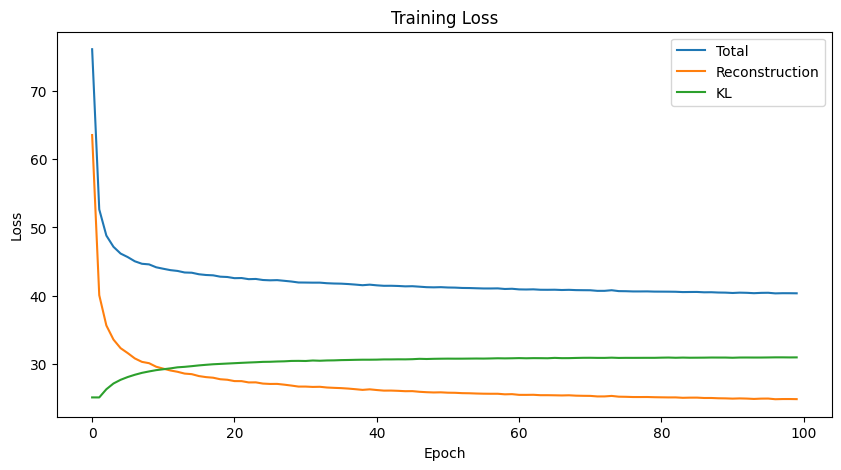

In [117]:
#plotting
plt.figure(figsize=(10,5))
plt.plot(train_losses, label="Total")
plt.plot(recon_losses, label="Reconstruction")
plt.plot(kl_losses, label="KL")
plt.legend()
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [118]:
torch.save(model.state_dict(), "m22aie202_vae_cifar.pth")

In [119]:
model.eval()

with torch.no_grad():
    z = torch.randn(16, latent_dim).to(device)
    samples = model.decoder(z).cpu()

In [120]:
grid = make_grid(samples, nrow=4)

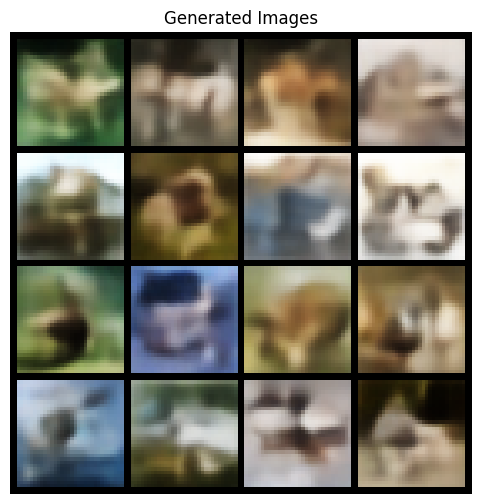

In [121]:
plt.figure(figsize=(6,6))
plt.imshow(np.transpose(grid, (1,2,0)))
plt.axis("off")
plt.title("Generated Images")
plt.show()

In [122]:
z1 = torch.randn(1, latent_dim).to(device)
z2 = torch.randn(1, latent_dim).to(device)

In [123]:
alphas = torch.linspace(0, 1, 10).to(device)

In [124]:
model.eval()
images = []

with torch.no_grad():
    for a in alphas:
        z = (1 - a) * z1 + a * z2
        img = model.decoder(z)
        images.append(img)

images = torch.cat(images, dim=0).cpu()

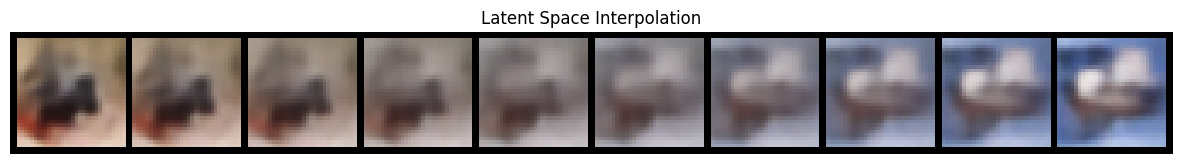

In [125]:
grid = make_grid(images, nrow=10)

plt.figure(figsize=(15,3))
plt.imshow(np.transpose(grid, (1,2,0)))
plt.axis("off")
plt.title("Latent Space Interpolation")
plt.show()

In [126]:
beta_model = VAE(latent_dim).to(device)
beta_model.load_state_dict(model.state_dict())

<All keys matched successfully>

In [127]:
beta_optimizer = torch.optim.Adam(beta_model.parameters(), lr=1e-4)

In [134]:
beta = .2
beta_epochs = 15

In [135]:
for epoch in range(beta_epochs):
    beta_model.train()

    total_loss = 0

    for x, _ in train_loader:
        x = x.to(device)

        beta_optimizer.zero_grad()

        recon, mu, logvar = beta_model(x)
        loss, _, _ = vae_loss(recon, x, mu, logvar, beta)

        loss.backward()
        beta_optimizer.step()

        total_loss += loss.item()

    print(f"Beta Epoch [{epoch+1}/{beta_epochs}] Loss: {total_loss/len(train_loader.dataset):.4f}")

Beta Epoch [1/15] Loss: 28.7169
Beta Epoch [2/15] Loss: 28.4774
Beta Epoch [3/15] Loss: 28.4098
Beta Epoch [4/15] Loss: 28.3930
Beta Epoch [5/15] Loss: 28.3220
Beta Epoch [6/15] Loss: 28.2814
Beta Epoch [7/15] Loss: 28.2605
Beta Epoch [8/15] Loss: 28.2295
Beta Epoch [9/15] Loss: 28.2149
Beta Epoch [10/15] Loss: 28.1943
Beta Epoch [11/15] Loss: 28.1749
Beta Epoch [12/15] Loss: 28.1569
Beta Epoch [13/15] Loss: 28.1257
Beta Epoch [14/15] Loss: 28.1145
Beta Epoch [15/15] Loss: 28.1053


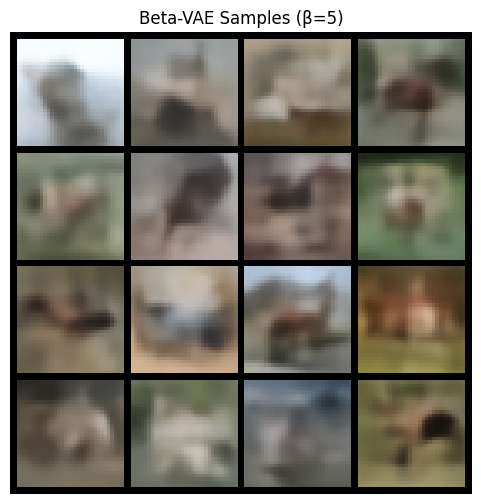

In [136]:
beta_model.eval()

with torch.no_grad():
    z = torch.randn(16, latent_dim).to(device) * 0.7
    samples = beta_model.decoder(z).cpu()

grid = make_grid(samples, nrow=4)

plt.figure(figsize=(6,6))
plt.imshow(np.transpose(grid, (1,2,0)))
plt.axis("off")
plt.title("Beta-VAE Samples (β)")
plt.show()

In this experiment I changed the value of β to understand how it affects image generation and the structure of the latent space. I tried β = 0.1, 0.2, 0.5, 1 and 5, and the differences were very clear.

When β was small (0.1 or 0.2), the model focused more on reconstructing the images. The outputs looked better compared to larger β values. I could see stronger shapes, better color separation, and slightly more recognizable objects. However, the latent space felt less controlled. During interpolation, the changes between images were sometimes uneven, which suggests the representations were not very well organized.

As β increased to around 0.5 and 1, the model reached a balance. The images became a bit blurrier, but they looked more stable. Interpolations were smoother and more gradual, meaning nearby latent points produced similar outputs. This indicates a more continuous and structured latent space.

When β was set to 5, the effect of compression became very strong. The generated images turned much smoother and lost many details. It became hard to recognize specific objects. This happened because the model was forced to store less information in the latent vector.